In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon
import time
from scipy.optimize import linear_sum_assignment

from dataclasses import dataclass

@dataclass
class DetectedObject:
    id: int
    center: np.ndarray
    heading: float # orientiation of the object in the world frame
    length: float
    width: float
    corners: np.ndarray

In [2]:
def angle_difference(a, b):
    '''
    Smallest signed difference from angle a to angle b, wrapped to the range -pi to +pi. This is done 
    in case there are scenarioswhere the heading angles are something like 2 degrees and 358 degrees. 
    The difference in measured heading angles is 356 degrees but they are better described as being 
    4 degrees apart. This is used in resolve_heading_ambiguity().
    '''
    return (a - b + np.pi) % (2 * np.pi) - np.pi


def angular_lerp(a, b, alpha):
    '''
    Using linear interpolation (lerp) from angle a to angle b, find the angle that is alpha % of the
    distance between angle a and angle b. alpha=0 returns angle a, and alpha=1 returns angle b.
    '''
    return a + alpha * angle_difference(b, a)


def resolve_heading_ambiguity(track_heading, meas_heading, meas_length, meas_width):
    '''
    fit_rectangle() only searches theta over [0, 90 deg), since a rectangle's edges are
    indistinguishable under 90-degree rotation. So a single physical orientation can show up as
    meas_heading, meas_heading+90, +180, or +270 depending on which face of the object the LiDAR
    sees. We pick whichever of those 4 candidates is closest to the track's current heading,
    swapping length/width for the +90/+270 cases since the roles of the two edges swap with them.
    '''
    best = None
    best_difference = np.inf

    for i in range(4):
        candidate_heading = meas_heading + i * (np.pi / 2)
        if i % 2 == 0:
            candidate_length, candidate_width = meas_length, meas_width
        else:
            candidate_length, candidate_width = meas_width, meas_length

        difference = abs(angle_difference(candidate_heading, track_heading))
        if difference < best_difference:
            best_difference = difference
            best = (candidate_heading, candidate_length, candidate_width)

    return best


def reconstruct_corners(center, heading, length, width):
    '''
    Rebuilds the 4 rectangle corners from a (smoothed) center/heading/length/width, using the same
    corner ordering as fit_rectangle(). Used so the published box actually matches the
    smoothed heading, rather than showing the previous frame's raw, noisier corners.
    '''
    e1 = np.array([np.cos(heading), np.sin(heading)])
    e2 = np.array([-np.sin(heading), np.cos(heading)])
    half_l, half_w = length / 2, width / 2

    return np.array([
        center - half_l * e1 - half_w * e2,
        center + half_l * e1 - half_w * e2,
        center + half_l * e1 + half_w * e2,
        center - half_l * e1 + half_w * e2
    ])

In [3]:
class KalmanFilter:
    '''
    Standard linear Kalman filter with a constant-velocity motion model for 2D position.
    State: x = [px, py, vx, vy]^T. We only ever measure position (px, py); velocity is inferred.
    '''

    def __init__(self, initial_position, dt, process_noise_std=1.0, measurement_noise_std=0.1):
        self.dt = dt

        # define the state vector of 2D position and 2D velocity
        self.x = np.array([initial_position[0], initial_position[1], 0.0, 0.0])

        # define the state covairance matrix i.e. the uncertainty of the state vector
        # assume that the there is confidence in the initial position, but larger 
        # uncertainty of the inital state velocity
        self.P = np.diag([1.0, 1.0, 10.0, 10.0])

        # define the state transition matrix i.e. how the model changes over time
        self.F = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1, 0],
            [0, 0, 0, 1]
        ])

        # measurement matrix, used to acquire the (x,y) components of the state/covariance matricies
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        self._set_process_noise(process_noise_std)

        # measurement noise covariance matrix
        r = measurement_noise_std**2
        self.R = np.diag([r, r])

    def _set_process_noise(self, process_noise_std):
        # discretized white-noise-acceleration model, decoupled between x and y
        q = process_noise_std**2
        dt2 = self.dt**2
        dt3 = self.dt**3
        dt4 = self.dt**4
        self.Q = q * np.array([
            [dt4 / 4,       0, dt3 / 2,       0],
            [      0, dt4 / 4,       0, dt3 / 2],
            [dt3 / 2,       0,     dt2,       0],
            [      0, dt3 / 2,       0,     dt2]
        ])

    def predict(self, dt=None):
        '''
        Intakes the current system state and outputs the next predicted state and its uncertainty
        '''
        if dt is not None and dt != self.dt:
            self.dt = dt
            self.F[0, 2] = dt
            self.F[1, 3] = dt
            self._set_process_noise(np.sqrt(self.Q[2, 2] / (self.dt ** 2)) if self.dt > 0 else 1.0)

        # predicted state
        self.x = self.F @ self.x

        # predicted estimate covariance
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, measurement):
        '''
        Intakes the current system state and a new measurement and outputs the updated state and its uncertainty
        '''
        z = np.array(measurement)
        y = z - self.H @ self.x                     # innovation / measurement residual
        S = self.H @ self.P @ self.H.T + self.R     # innovation / residual covariance
        K = self.P @ self.H.T @ np.linalg.inv(S)    # Kalman gain

        # update the state estimate and state estimate covariance
        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P

    @property
    def position(self):
        return self.x[:2]

    @property
    def velocity(self):
        return self.x[2:4]
    

class Track:
    '''
    Class object for a single tracked object: a Kalman filter for position/velocity, plus smoothed heading and
    dimensions (handled separately from the KF for the reasons in resolve_heading_ambiguity).

    This class object allows for multiple objects to be tracked individually and 
    implements the update and prediction functions from the KalmanFilter class.
    '''

    def __init__(self, track_id, detected_object, dt):
        self.id = track_id
        self.kf = KalmanFilter(initial_position=detected_object.center, dt=dt)

        self.heading = detected_object.heading
        self.length = detected_object.length
        self.width = detected_object.width
        self.corners = detected_object.corners

        self.age = 1
        self.hits = 1 # tracking total hits
        self.hit_streak = 1 # tracking consecutive hits
        self.time_since_update = 0

    def predict(self, dt):
        self.kf.predict(dt)
        self.age += 1
        if self.time_since_update > 0:
            self.hit_streak = 0
        self.time_since_update += 1

    def update(self, detected_object, heading_smoothing=0.6, size_smoothing=0.6):
        self.kf.update(detected_object.center)

        heading, length, width = resolve_heading_ambiguity(
            self.heading, detected_object.heading, detected_object.length, detected_object.width
        )

        # get the new heading angle, length, width and corners of the tracked rectangle object
        self.heading = angular_lerp(self.heading, heading, heading_smoothing)
        self.length = (1 - size_smoothing) * self.length + size_smoothing * length
        self.width = (1 - size_smoothing) * self.width + size_smoothing * width
        self.corners = reconstruct_corners(self.center, self.heading, self.length, self.width)

        self.hits += 1
        self.hit_streak += 1
        self.time_since_update = 0

    @property
    def center(self):
        return self.kf.position

    @property
    def velocity(self):
        return self.kf.velocity


class KalmanTracker:
    '''
    This is a multi-object tracker that predicts the tracks forward, associates detected objects to tracks via
    the Hungarian algorithm with a Euclidean-distance cost matrix.

    To ensure that tracking is not done for random objects that barely show up or are unstable, min_hits defines
    how many consecutively matched frames must be found before that track is published. if an object is being tracked
    but then is missed for some reason, then those tracks are removed and is controlled via max_age. To also ensure
    that the tracker is validly tracking a moving object (and to ensure that tracked objects don't get mixed up with
    one another), the max_valid_distance variable ensures that the distance between a predicted track and a detected
    object falls within the range of max_valid_distance (m)
    '''

    def __init__(self, max_age=5, min_hits=3, max_valid_distance=1.5):
        self.max_age = max_age
        self.min_hits = min_hits
        self.max_valid_distance = max_valid_distance
        self.tracks = []
        self._next_id = 0

    def step(self, detected_objects, dt):
        '''
        Advances all tracks by dt, associates detected objects, and returns the confirmed tracks.
        '''
        for track in self.tracks:
            track.predict(dt)

        matches, unmatched_tracks, unmatched_detections = self._associate(detected_objects)

        # update the tracks that have been associated with the newly detected objects
        for track_idx, det_idx in matches:
            self.tracks[track_idx].update(detected_objects[det_idx])

        # for any new, unmatched/associated objects, add them to the list tracks for association and predictions
        for det_idx in unmatched_detections:
            self.tracks.append(Track(self._next_id, detected_objects[det_idx], dt))
            self._next_id += 1

        self.tracks = [t for t in self.tracks if t.time_since_update <= self.max_age]

        # check for valid tracks based on the criteria of max_age before a track is pruned, 
        # consequetive hits via hit_streak, and min hits before a track is considered valid for publishing
        valid_tracks = self._get_confirmed_tracks()

        return valid_tracks

    def _associate(self, detected_objects):
        # if there hasn't been any tracked objects yet, return no matches, and all tracks and objects are unmatched
        if len(self.tracks) == 0 or len(detected_objects) == 0:
            return [], list(range(len(self.tracks))), list(range(len(detected_objects)))

        # create the euclidean distance cost matrix for the hungarian algorithm
        # this matrix is the euclidean distance between the tracked object center and the detected object center
        cost_matrix = np.zeros((len(self.tracks), len(detected_objects)))
        for t, track in enumerate(self.tracks):
            for d, detected_object in enumerate(detected_objects):
                cost_matrix[t, d] = np.linalg.norm(track.center - np.array(detected_object.center))

        # this is the hungarian algorithm via scipy. When you search "hungarian algorithm python" this is what you are recommended
        track_indices, det_indices = linear_sum_assignment(cost_matrix)

        matches = []
        unmatched_tracks = list(range(len(self.tracks)))
        unmatched_detections = list(range(len(detected_objects)))

        # using the max_valid_distance, check the indicies recieved from the Hungarian algorithm
        # to see if the cost matrix at those indicies fall within the valid distance
        for t, d in zip(track_indices, det_indices):
            if cost_matrix[t, d] > self.max_valid_distance:
                continue  # optimal assignment, but too far away to trust
            matches.append((t, d))
            unmatched_tracks.remove(t)
            unmatched_detections.remove(d)

        return matches, unmatched_tracks, unmatched_detections

    def _get_confirmed_tracks(self):
        '''
        Validate the tracks based on the criteria defined in the class description
        '''
        confirmed = []
        for track in self.tracks:
            if track.hit_streak >= self.min_hits and track.time_since_update == 0:
                confirmed.append(track)
        return confirmed



In [4]:
def calculate_closeness_criterion(C1, C2, d0):
    '''
    Optimization function for the fit_rectangle function. Optimizes the rectangle 
    fitting based on the closeness of the cluster points to the fitted rectangle edges
    '''
    # c1_min and c1_max are the boundaries on axis e1_hat, the rectangle edge direction vector (same goes for e2_hat)
    c1_max = np.max(C1)
    c1_min = np.min(C1)
    c2_max = np.max(C2)
    c2_min = np.min(C2)

    D1 = np.minimum(c1_max - C1, C1 - c1_min)
    D2 = np.minimum(c2_max - C2, C2 - c2_min)

    d = np.maximum(np.minimum(D1, D2), d0)

    return np.sum(1.0 / d)

def fit_rectangle(cluster, d0, id):
    '''
    Implementation of the Search-Based Rectangle Fitting algorithm. For 2D LiDAR scans, points clusters
    are often seen as L-shapes. This function efficiently fits a rectangle to the given cluster of points.
    The points are already clustered via the Euclidean Clustering algorithm from the get_euclidean_clusters function
    '''
    # the inputs into the criterion functions are C1 and C2 which are the projections of all the range points on the two orthogonal edges determined by theta
    thetas = np.linspace(0, 90, 89, endpoint=False) * np.pi / 180
    q_max = 0
    optimal_theta = 0
    for theta in thetas:
        # rectangle edge direction vectors
        e1_hat = np.array([np.cos(theta), np.sin(theta)])
        e2_hat = np.array([-np.sin(theta), np.cos(theta)])

        # projections on to the edge
        C1 = np.dot(cluster, e1_hat)
        C2 = np.dot(cluster, e2_hat)

        q = calculate_closeness_criterion(C1, C2, d0)
        if q > q_max: 
            q_max = q
            optimal_theta = theta
    
    # with the optimal rectangle angle determined, we can now reconstruct the rectangle
    e1 = np.array([np.cos(optimal_theta), np.sin(optimal_theta)])
    e2 = np.array([-np.sin(optimal_theta), np.cos(optimal_theta)])

    C1 = cluster @ e1
    C2 = cluster @ e2

    c1_min = np.min(C1)
    c1_max = np.max(C1)
    c2_max = np.max(C2)
    c2_min = np.min(C2)

    e1 = np.array([np.cos(optimal_theta), np.sin(optimal_theta)])
    e2 = np.array([-np.sin(optimal_theta), np.cos(optimal_theta)])

    rectangle_corners = np.array([
        c1_min * e1 + c2_min * e2,
        c1_max * e1 + c2_min * e2,
        c1_max * e1 + c2_max * e2,
        c1_min * e1 + c2_max * e2
    ])

    rectangle_center = np.array([(rectangle_corners[0][0] + rectangle_corners[2][0])/2, (rectangle_corners[0][1] + rectangle_corners[2][1])/2])
    length = np.linalg.norm(rectangle_corners[0] - rectangle_corners[1])
    width = np.linalg.norm(rectangle_corners[0] - rectangle_corners[3])

    obj = DetectedObject(
        id = id,
        center = rectangle_center,
        heading = optimal_theta,
        length = length,
        width = width,
        corners = rectangle_corners
    )
    return obj

fitting time: 0.0016274452209472656 seconds
[-14.35172647  -7.1963319 ]
[18.21906221 -1.97868169]
[13.50320252 27.45971739]
[-19.06758616  22.24206718]
fitting time: 0.0016067028045654297 seconds
[42.82178014 16.1455109 ]
[75.83506858 19.65462563]
[72.16912244 54.14336328]
[39.15583401 50.63424856]
fitting time: 0.0015358924865722656 seconds
[11.62136062 60.07768615]
[25.64754785 94.36705122]
[14.02618723 99.12081028]
[3.55271368e-15 6.48314452e+01]


C:\Users\admin-pc\AppData\Local\Temp\ipykernel_66916\429536570.py:9: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  points.append(np.random.multivariate_normal(means[i], covs[i], 1000))


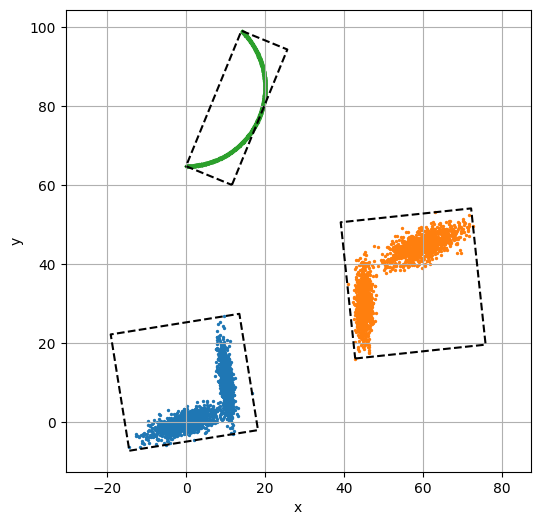

In [10]:
# testing the object clustering and rectangle fitting

# manually create the L-shape corners a 2D LiDAR might see by generate gaussians close to each other in a sort of L shape
means = np.array([[0, 0], [10, 11], [60, 45], [45, 30]])
covs = np.array([[[20, 8], [8, 1]], [[1, -4], [-2, 20]], [[20, 10], [10, 1]], [[1, 0], [0, 20]]])

points = []
for i in range(len(means)):
    points.append(np.random.multivariate_normal(means[i], covs[i], 1000))

# generate a semicircle perimeter that a 2D LiDAR might see
def generate_semicircle(center, radius, num_points):
    theta = np.linspace(0, -np.pi + np.deg2rad(45), num_points)

    r = radius + np.random.normal(0, 0.05, num_points)

    x = center[0] + r * np.cos(theta)
    y = center[1] + r * np.sin(theta)

    return np.column_stack((x, y))

# rotate the circle as desired
def rotate(points, angle):
    R = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])

    return points @ R.T

semicircle = generate_semicircle(
    center=(60, 60),
    radius=20,
    num_points=2000
)

semicircle = rotate(semicircle, np.deg2rad(45))

# group all the clusters of points into one clusters array
clusters = np.array([np.concatenate((points[0], points[1])), np.concatenate((points[2], points[3])), semicircle])

plt.figure(figsize=(6, 6))
for i, cluster in enumerate(clusters):
    start_time = time.time()
    obj = fit_rectangle(cluster, d0=5, id=i) # test the rectangular fitting algorithm
    end_time = time.time()
    print('fitting time:', end_time-start_time, 'seconds')

    rectangle_corners = obj.corners

    print(rectangle_corners[0])
    print(rectangle_corners[1])
    print(rectangle_corners[2])
    print(rectangle_corners[3])

    x_coords = [rectangle_corners[0][0], rectangle_corners[1][0], rectangle_corners[2][0], rectangle_corners[3][0], rectangle_corners[0][0]]
    y_coords = [rectangle_corners[0][1], rectangle_corners[1][1], rectangle_corners[2][1], rectangle_corners[3][1], rectangle_corners[0][1]]

    plt.plot(x_coords, y_coords, linestyle='--', color='black')
    plt.scatter(cluster[:,0], cluster[:,1], s=2)
plt.axis("equal")
plt.xlabel('x')
plt.ylabel('y')
plt.grid('both')
plt.show()

In [11]:
@dataclass
class GroundTruthObject:
    start_pos: np.ndarray
    velocity: np.ndarray      # constant velocity, m/s
    heading: float            # constant heading, radians
    length: float
    width: float

    def position(self, t):
        return self.start_pos + self.velocity * t

# three synthetic objects:
#  - obj A: moves diagonally, straightforward case
#  - obj B: crosses obj A's path -- stresses the Hungarian association
#  - obj C: appears late and gets occluded partway through -- stresses track survival
ground_truth = {
    'A': GroundTruthObject(np.array([0.0, 0.0]),   np.array([1.0, 0.5]),  np.deg2rad(30), length=4.0, width=2.0),
    'B': GroundTruthObject(np.array([10.0, 0.0]),  np.array([-1.0, 0.5]), np.deg2rad(70), length=3.5, width=1.8),
    'C': GroundTruthObject(np.array([-5.0, 8.0]),  np.array([0.8, -0.2]), np.deg2rad(10), length=4.5, width=2.2),
}

dt = 0.1
n_frames = 100

In [12]:
def simulate_detection(gt_obj, t, rng, pos_noise_std=0.05, heading_noise_std=np.deg2rad(2)):
    '''Generates one noisy DetectedObject the way your real detector would, including
    the 90-degree heading/dimension ambiguity fit_rectangle() produces.'''
    true_pos = gt_obj.position(t)
    noisy_pos = true_pos + rng.normal(0, pos_noise_std, 2)

    # fit_rectangle only ever returns theta in [0, 90 deg) -- simulate that by wrapping,
    # then randomly picking which of the 4 equivalent representations comes out this frame
    # (mimics the face of the object the LiDAR happens to see)
    k = rng.integers(0, 4)
    raw_heading = (gt_obj.heading + k * (np.pi / 2)) % (np.pi / 2)
    raw_heading += rng.normal(0, heading_noise_std)

    if k % 2 == 0:
        length, width = gt_obj.length, gt_obj.width
    else:
        length, width = gt_obj.width, gt_obj.length
    length += rng.normal(0, 0.05)
    width += rng.normal(0, 0.05)

    corners = reconstruct_corners(noisy_pos, raw_heading, length, width)

    return DetectedObject(id=0, center=noisy_pos, heading=raw_heading,
                           length=length, width=width, corners=corners)


def generate_frame_detections(t, rng, occlude_c_between=(3.0, 5.0), clutter_prob=0.1):
    detections = []
    for name, gt_obj in ground_truth.items():
        if name == 'C' and occlude_c_between[0] <= t <= occlude_c_between[1]:
            continue  # simulate object C being occluded for ~2 seconds
        detections.append(simulate_detection(gt_obj, t, rng))

    # occasional spurious clutter detection (e.g. a stray reflection)
    if rng.random() < clutter_prob:
        clutter_pos = rng.uniform(-10, 15, 2)
        detections.append(DetectedObject(
            id=0, center=clutter_pos, heading=rng.uniform(0, np.pi/2),
            length=0.3, width=0.3,
            corners=reconstruct_corners(clutter_pos, 0.0, 0.3, 0.3)
        ))
    return detections

In [14]:
rng = np.random.default_rng(seed=42)
tracker = KalmanTracker(max_age=5, min_hits=3, max_valid_distance=1.5)

history = []  # one entry per frame: {'t':, 'confirmed': [...], 'all_tracks': [...], 'detections': [...]}

for frame in range(n_frames):
    t = frame * dt
    detections = generate_frame_detections(t, rng)
    confirmed = tracker.step(detections, dt)

    history.append({
        't': t,
        'confirmed': [(trk.id, trk.center.copy(), trk.velocity.copy(), trk.heading) for trk in confirmed],
        'n_total_tracks': len(tracker.tracks),
        'detections': [d.center.copy() for d in detections],
    })

print(f"Ran {n_frames} frames. Final live track count: {len(tracker.tracks)}")

Ran 100 frames. Final live track count: 4


In [15]:
from collections import defaultdict

# figure out, for each frame, which track is closest to each ground-truth object
closest_track_per_gt = defaultdict(list)
for entry in history:
    t = entry['t']
    for name, gt_obj in ground_truth.items():
        true_pos = gt_obj.position(t)
        if not entry['confirmed']:
            continue
        best = min(entry['confirmed'], key=lambda trk: np.linalg.norm(trk[1] - true_pos))
        dist = np.linalg.norm(best[1] - true_pos)
        if dist < 1.0:  # only count it as "found" if reasonably close
            closest_track_per_gt[name].append((t, best[0]))

for name, matches in closest_track_per_gt.items():
    ids_used = set(m[1] for m in matches)
    status = "OK" if len(ids_used) == 1 else "ID SWAP DETECTED"
    print(f"Object {name}: track IDs used over its lifetime = {ids_used}  [{status}]")

Object A: track IDs used over its lifetime = {0}  [OK]
Object B: track IDs used over its lifetime = {0, 1}  [ID SWAP DETECTED]
Object C: track IDs used over its lifetime = {9, 2}  [ID SWAP DETECTED]


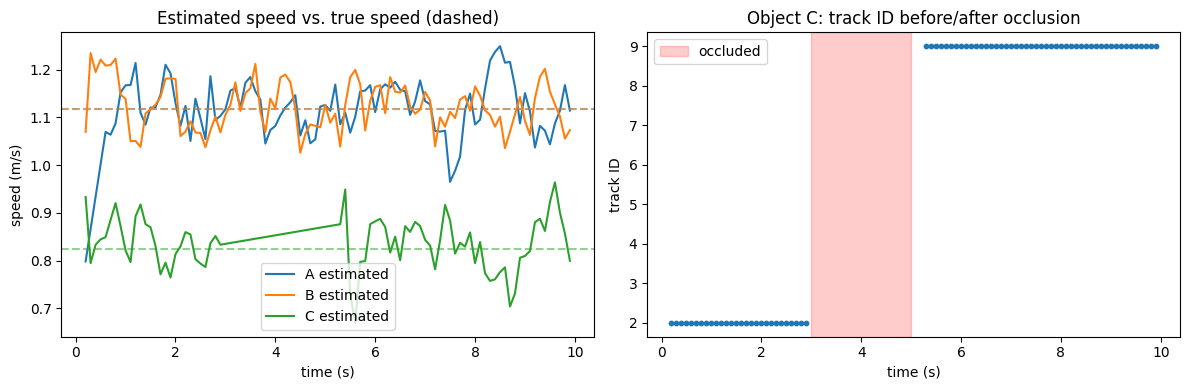

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, matches in closest_track_per_gt.items():
    gt_obj = ground_truth[name]
    ts = [m[0] for m in matches]
    ids = [m[1] for m in matches]
    est_vel = []
    for t, tid in matches:
        entry = history[int(round(t/dt))]
        trk = next(trk for trk in entry['confirmed'] if trk[0] == tid)
        est_vel.append(trk[2])
    est_vel = np.array(est_vel)
    true_speed = np.linalg.norm(gt_obj.velocity)
    est_speed = np.linalg.norm(est_vel, axis=1)

    axes[0].plot(ts, est_speed, label=f'{name} estimated')
    axes[0].axhline(true_speed, linestyle='--', color=axes[0].lines[-1].get_color(), alpha=0.5)

axes[0].set_xlabel('time (s)'); axes[0].set_ylabel('speed (m/s)')
axes[0].set_title('Estimated speed vs. true speed (dashed)')
axes[0].legend()

# occlusion recovery: plot object C's track ID over time -- should have a gap, then resume same ID
c_matches = closest_track_per_gt['C']
axes[1].scatter([m[0] for m in c_matches], [m[1] for m in c_matches], s=10)
axes[1].axvspan(3.0, 5.0, alpha=0.2, color='red', label='occluded')
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('track ID')
axes[1].set_title('Object C: track ID before/after occlusion')
axes[1].legend()
plt.tight_layout()
plt.show()

In [17]:
frame_ids_published = [set(tid for tid, *_ in entry['confirmed']) for entry in history]
first_seen = {}
for frame_idx, ids in enumerate(frame_ids_published):
    for tid in ids:
        first_seen.setdefault(tid, frame_idx)

print("First frame each published ID appeared on (should never be frame 0 or 1 given min_hits=3):")
print(sorted(first_seen.items()))

max_id_ever_created = tracker._next_id
ids_confirmed_ever = set(first_seen.keys())
print(f"\n{max_id_ever_created} tracks were created total, but only {len(ids_confirmed_ever)} were ever confirmed/published.")
print("The gap between these two numbers is roughly your clutter rejection rate.")

First frame each published ID appeared on (should never be frame 0 or 1 given min_hits=3):
[(0, 2), (1, 2), (2, 2), (9, 53)]

15 tracks were created total, but only 4 were ever confirmed/published.
The gap between these two numbers is roughly your clutter rejection rate.


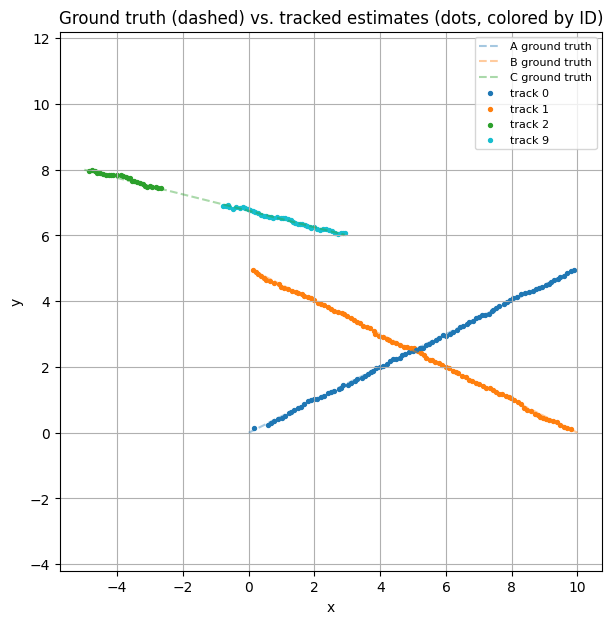

In [18]:
plt.figure(figsize=(7, 7))
colors = plt.cm.tab10.colors

for name, gt_obj in ground_truth.items():
    ts = np.arange(0, n_frames * dt, dt)
    true_path = np.array([gt_obj.position(t) for t in ts])
    plt.plot(true_path[:, 0], true_path[:, 1], '--', alpha=0.4, label=f'{name} ground truth')

seen_ids = set()
for entry in history:
    for tid, pos, vel, heading in entry['confirmed']:
        color = colors[tid % len(colors)]
        label = f'track {tid}' if tid not in seen_ids else None
        seen_ids.add(tid)
        plt.scatter(pos[0], pos[1], s=8, color=color, label=label)

plt.axis('equal'); plt.grid(True); plt.legend(fontsize=8)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Ground truth (dashed) vs. tracked estimates (dots, colored by ID)')
plt.show()